In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


print("Libraries successfully imported!")


Libraries successfully imported!


In [2]:

df = pd.read_csv(r"D:\ML_PROJECTS\Customer_Segmentation\data\raw\Mall_Customers.csv")



display(df.head())

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
display(df.isnull().sum())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Dataset Shape: (200, 5)

Missing Values:


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_22780\3280388182.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


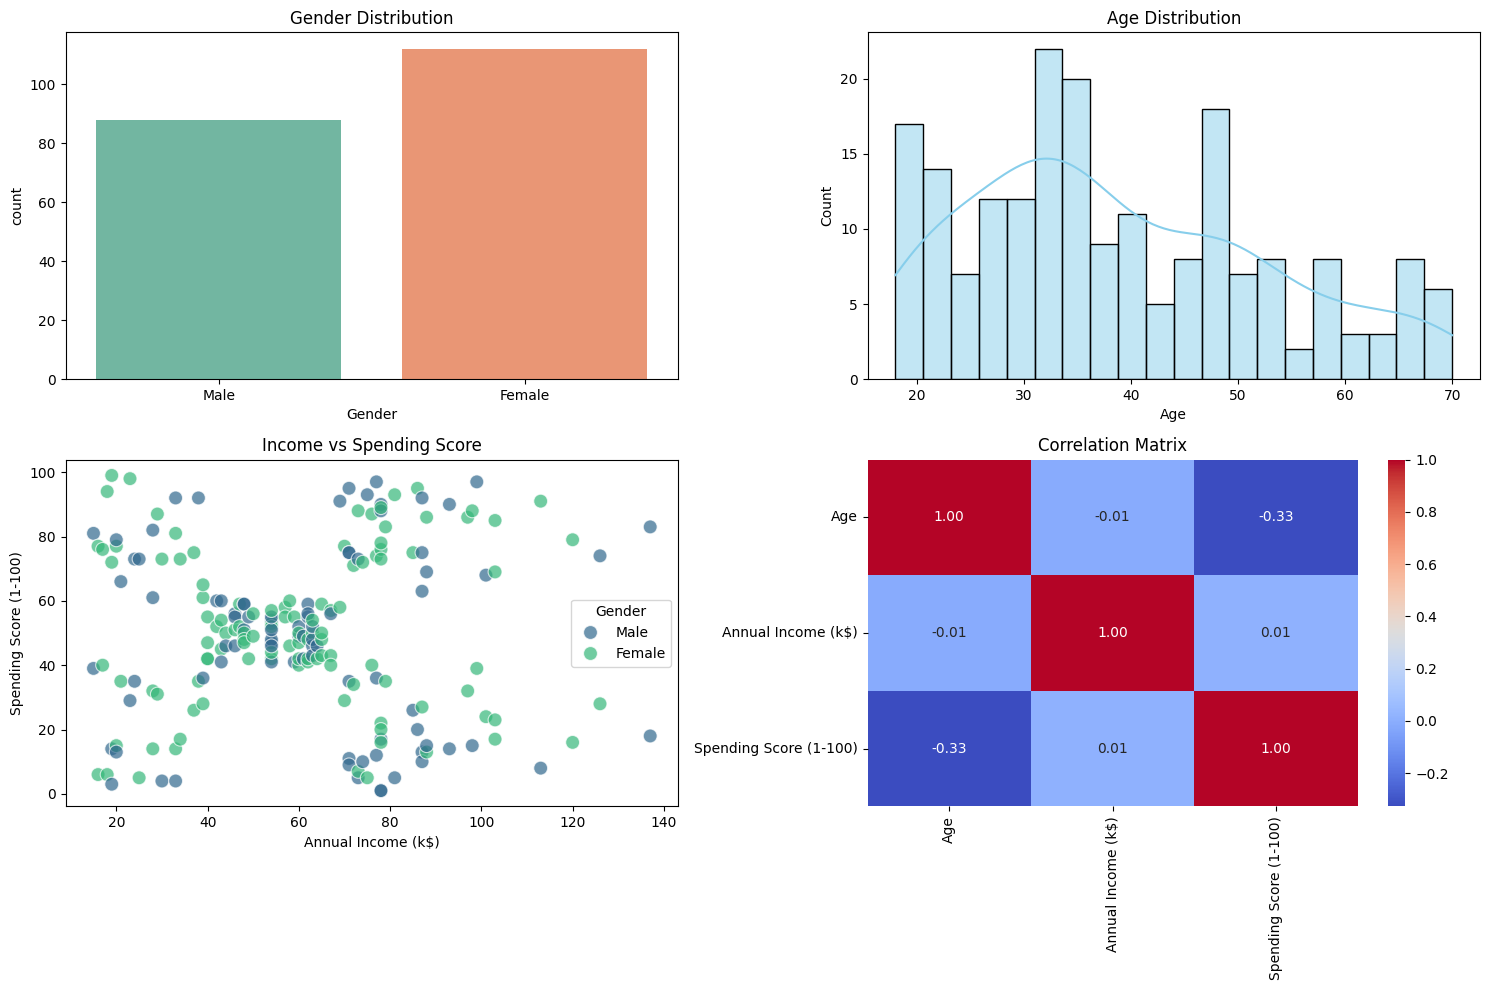

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')


plt.subplot(2, 2, 2)
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')


plt.subplot(2, 2, 3)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Income vs Spending Score')


plt.subplot(2, 2, 4)

corr_matrix = df.drop(['CustomerID', 'Gender'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

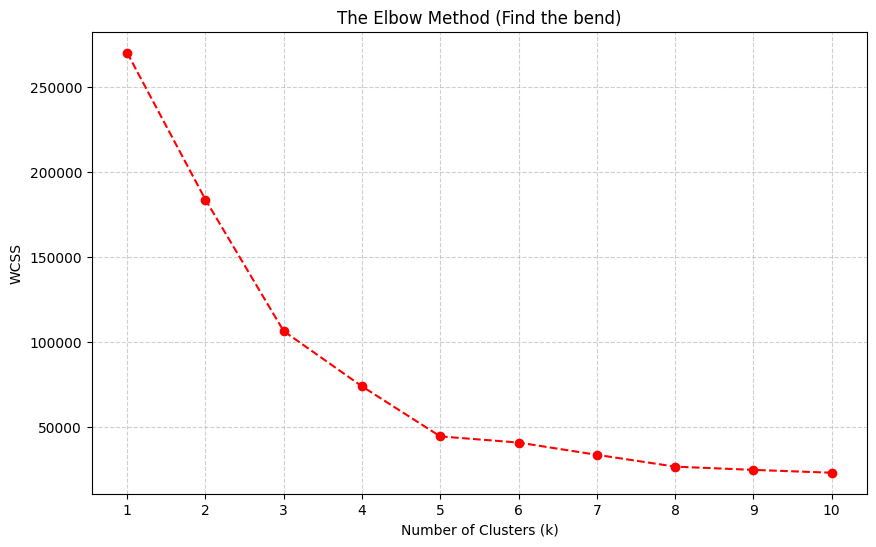

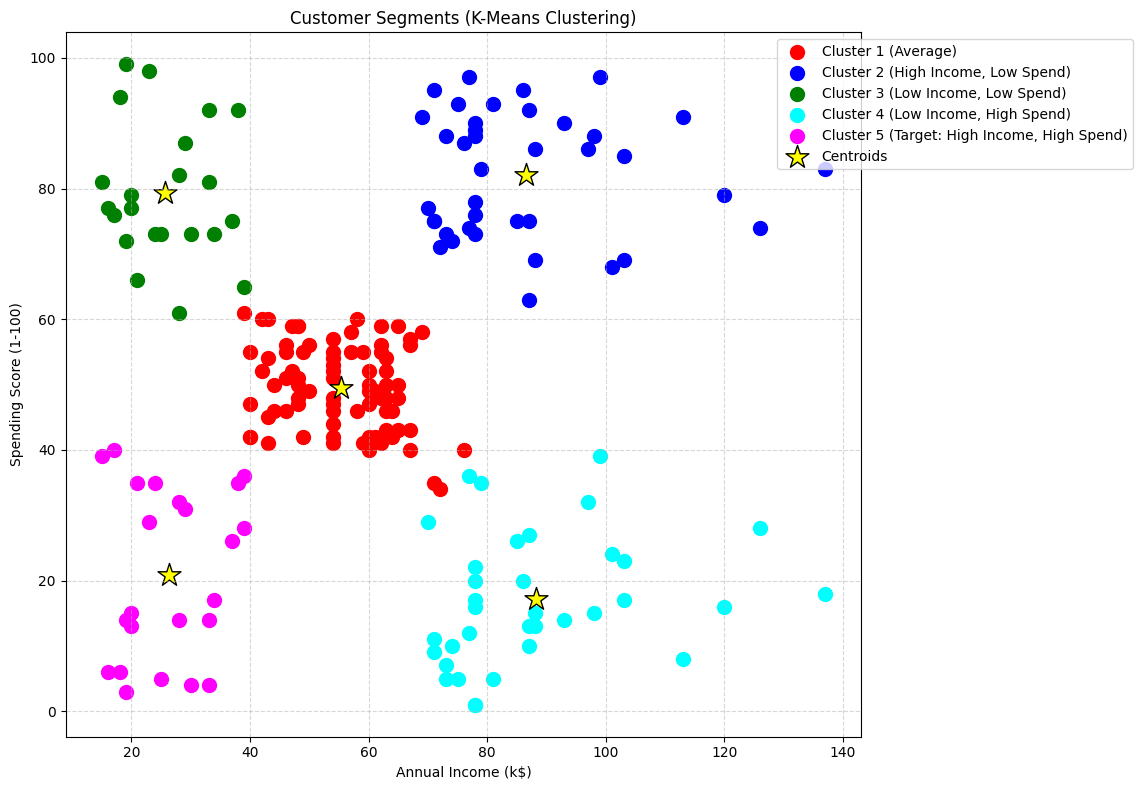

In [7]:

from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt


X = df.iloc[:, [3, 4]].values

wcss = [] 


for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method (Find the bend)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)


plt.figure(figsize=(12, 8))


plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Average)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (High Income, Low Spend)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 (Low Income, Low Spend)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4 (Low Income, High Spend)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5 (Target: High Income, High Spend)')


plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()